# Japan — F-Score grid study: basket k = 30, random draws = 5000

One cell of the reviewer-suggested 3 x 3 x 2 grid (basket sizes 20/25/30 x
random-sample sizes 1,000/2,000/5,000 x two markets). Signals come from
the team's FS_clean statements, scored by this repository's own signal code
(`fscore.signal.piotroski`, unit-tested, beginning-of-year asset scaling on
both sides of every delta); prices from the cached Yahoo data. Formations are
July 1 of **2012-2024** (13 chained holding years, each a full twelve
months) using score year T-1 — one conservative timing rule for both markets,
over identical calendar time so the two are comparable. July 2024 is the last
formation whose complete year finishes inside the sample.
Covariances are estimated on 36 months of daily returns ending the day
before formation. Note the panel resolves to *currently listed* symbols, so
the universe is survivorship-tilted — disclosed as a data limitation. The value control falls back to the universe
in years before B/M coverage begins (flagged in the diagnostics).

Peer-review design points (see `src/fscore/grid.py` docstring): explicit
random basis = full eligible universe with fresh draws each year and reported
overlap; a non-F-Score random control; strict F ≥ 8 portfolio; universe EW
and plain universe minimum-variance controls; a dollar-neutral long-short
book (long top-k scores, short bottom-k, charged both legs' trading costs
plus a stock-borrow fee) wherever shorting is available — Vietnam runs
long-only, so `fscore_LS` is simply absent there; denoised
(not detoned) GMV;
primary measure fixed in advance = the GROSS Sharpe ratio (rf = 0), with
turnover and net-of-cost figures reported separately; and the synergy test
D = Sharpe(GMV) − Sharpe(EW) computed per basket. All figures are saved at dpi = 300.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.fs_clean import exclusion_report, load_scores
from fscore.data.team_scores import sectors_from_scores
from fscore.grid import run_grid
from fscore.plotting import setup_plots, save_fig

setup_plots()          # study-wide figure defaults; every saved chart is 300 dpi
MARKET, K, N_MC = "japan", 30, 5000
YEARS = list(range(2012, 2025))
FIG = ROOT / "results" / "figures"
OUT = ROOT / "results" / "grid"; OUT.mkdir(parents=True, exist_ok=True)
TAG = "japan_k30_mc5000"

scores = load_scores(MARKET, ROOT / "data")   # our own signal code
prices = pd.read_csv(ROOT / "data" / f"{MARKET}_prices.csv.gz", parse_dates=["date"])
sectors = sectors_from_scores(scores)
study = run_grid(MARKET, scores, prices, sectors, YEARS, k=K, n_mc=N_MC,
                 n_gmv=300, seed=42)
diag = study.diagnostics()
diag.round(3)

,universe,dropped_no_price,bm_coverage,k,value_fallback,value_basket_size,n_fscore_high,fscore_mean,fscore_basket_min,tie_break_slots,overlap_random_vs_fscore,overlap_expected,cov_est_days,cov_min_est_days,delisted_in_holding_year,no_price_after_formation,long_short_run,short_leg_max_fscore
year,,,,,,,,,,,,,,,,,,
2012,78,3,0,30,True,78,22,6.769,7.0,8,0.385,0.385,733,366,0,0,True,7.0
2013,73,2,0,30,True,73,6,5.671,6.0,9,0.411,0.411,734,367,0,0,True,5.0
2014,81,2,0,30,True,81,16,6.148,7.0,14,0.370,0.370,736,368,0,0,True,5.0
2015,80,2,0,30,True,80,15,6.462,7.0,15,0.374,0.375,735,367,0,0,True,6.0
2016,79,2,0,30,True,79,16,6.266,7.0,14,0.378,0.380,734,367,0,0,True,6.0
2017,82,2,0,30,True,82,12,5.976,7.0,18,0.365,0.366,735,367,0,0,True,5.0
2018,82,1,0,30,True,82,18,6.476,7.0,12,0.365,0.366,750,375,0,0,True,6.0
2019,83,1,0,30,True,83,15,6.410,7.0,15,0.363,0.361,753,376,0,0,True,6.0
2020,81,0,0,30,True,81,4,5.716,6.0,8,0.370,0.370,751,375,0,0,True,5.0


### 0. Data discarded before any test

A firm-year enters the study only with a **complete nine-signal F-Score**.
Partial scores are dropped rather than summed over whatever is available —
an incomplete score is not a low score, and keeping them would push those
firms towards the bottom of the ranking and into the short leg.

Three things remove rows, counted separately because they mean different
things: an identifier that never resolved to a tradable symbol, a year with
no prior-year row to difference against, and a year whose nine signals were
not all computable. `dropped_no_price` in the diagnostics above counts the
further names removed for insufficient price history.

In [2]:
drops_total = exclusion_report(MARKET, ROOT / "data")
drops_year = exclusion_report(MARKET, ROOT / "data", by_year=True)
drops_total.to_csv(OUT / f"{TAG}_exclusions.csv")
r = drops_total.iloc[0]
print(f"{MARKET.upper()}: {int(r.rows_in_source)} firm-years in the source -> "
      f"{int(r.scored)} scored ({r.pct_scored:.1f}%)")
print(f"  identifier never resolved to a tradable symbol: {int(r.dropped_unresolved_identifier)}")
print(f"  no prior-year row to difference against:        {int(r.dropped_no_prior_year)}")
print(f"  nine signals not all computable:                {int(r.dropped_incomplete_signals)}")
drops_total

JAPAN: 2116 firm-years in the source -> 1876 scored (88.7%)
  identifier never resolved to a tradable symbol: 5
  no prior-year row to difference against:        235
  nine signals not all computable:                0


,rows_in_source,dropped_unresolved_identifier,dropped_incomplete_signals,scored,dropped_no_prior_year,pct_scored
japan,2116.0,5.0,0.0,1876.0,235.0,88.66


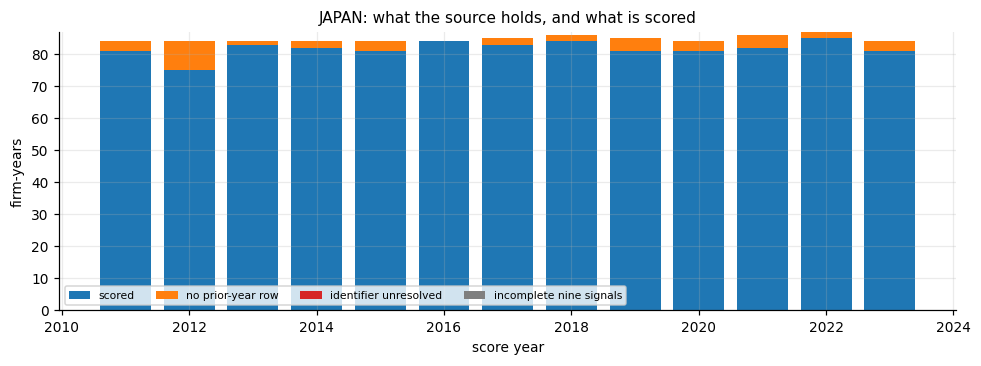

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.4))
b = drops_year.loc[[y - 1 for y in YEARS]]
ax.bar(b.index, b.scored, label="scored", color="tab:blue")
ax.bar(b.index, b.dropped_no_prior_year, bottom=b.scored,
       label="no prior-year row", color="tab:orange")
ax.bar(b.index, b.dropped_unresolved_identifier,
       bottom=b.scored + b.dropped_no_prior_year,
       label="identifier unresolved", color="tab:red")
ax.bar(b.index, b.dropped_incomplete_signals,
       bottom=b.scored + b.dropped_no_prior_year + b.dropped_unresolved_identifier,
       label="incomplete nine signals", color="tab:grey")
ax.set_xlabel("score year"); ax.set_ylabel("firm-years")
ax.set_title(f"{MARKET.upper()}: what the source holds, and what is scored")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout()
save_fig(f"{TAG}_exclusions", directory=FIG)
plt.show()

### 1. Summary (primary measure: **gross** Sharpe; rf = 0)

Gross performance is the cross-country convention — cost models differ by
market and would otherwise confound the comparison. Turnover is reported
beside it, and the net-of-cost columns follow as a sensitivity.

`nominal_k` is the basket size; `effective_n` is 1/Σw², the number of
holdings the weights actually amount to. They are not the same quantity: an
optimised or sector-capped book concentrates, so its effective N sits below
the names nominally held.

In [4]:
summary = study.summary()
summary[["ann_return", "ann_vol", "sharpe", "max_drawdown",
         "nominal_k", "effective_n"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,nominal_k,effective_n
fscore_EW,0.140,0.200,0.701,-0.360,30.0,30.000
fscore_GMV,0.127,0.177,0.715,-0.407,30.0,5.698
fscore_GMVsec,0.131,0.175,0.751,-0.361,30.0,8.020
fscore_high_EW,0.160,0.211,0.760,-0.325,22.0,12.308
value_EW,0.142,0.198,0.718,-0.318,78.0,66.692
universe_EW,0.139,0.193,0.720,-0.318,78.0,80.538
universe_GMV,0.132,0.161,0.816,-0.407,78.0,6.151
fscore_LS,0.008,0.073,0.111,-0.145,60.0,60.000


#### Turnover and the net-of-cost sensitivity (reported separately)

In [5]:
summary[["turnover", "cost_drag", "net_ann_return", "net_sharpe"]].round(4)

,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.6691,0.0027,0.1372,0.6873
fscore_GMV,0.7742,0.0031,0.1238,0.6980
fscore_GMVsec,0.7715,0.0031,0.1283,0.7337
fscore_high_EW,0.8442,0.0034,0.1566,0.7437
value_EW,0.2613,0.0010,0.1414,0.7128
universe_EW,0.1118,0.0004,0.1384,0.7177
universe_GMV,0.3408,0.0014,0.1302,0.8073
fscore_LS,1.3019,0.0152,-0.0071,-0.0980


### 2. Yearly returns (each formation held July–June, a full twelve months)

In [6]:
yearly = study.yearly_returns()
(yearly * 100).round(1)

,fscore_EW,fscore_GMV,fscore_GMVsec,fscore_high_EW,value_EW,universe_EW,universe_GMV,fscore_LS
date,,,,,,,,
2012,16.1,6.6,7.6,13.4,12.3,12.3,4.4,6.4
2013,49.2,57.5,58.1,42.8,51.4,51.4,38.3,-1.1
2014,16.7,49.2,43.7,16.4,13.2,13.2,39.9,7.4
2015,12.3,9.8,11.4,10.4,11.3,11.3,11.4,-0.1
2016,5.5,2.1,2.5,9.5,4.3,4.3,3.1,0.5
2017,18.6,34.5,30.5,16.5,25.1,25.1,38.4,-9.7
2018,-7.3,-23.3,-19.7,-4.0,-12.1,-12.1,-19.8,10.8
2019,11.5,6.8,9.4,17.9,14.2,14.2,3.0,-0.7
2020,0.1,-7.0,-4.1,6.4,6.6,6.6,-7.8,-5.2


### 3. Placement vs the random distributions

Reported gross and net of costs. The random control is redrawn every year, so
it carries its own turnover (~1 − k/|universe|) — charging both sides is the
like-for-like comparison; the gross rows show costs are not driving it.

Significance is judged at **one level fixed in advance: 5%** (`significant`
column = p < 0.05). There is no 1% or 10% tier: p = 0.06 is not
significant.

In [7]:
rows = {}
for pool, label in [("mc_ew", "random (full universe)"),
                    ("mc_nonf_ew", "random (non-F-Score names)")]:
    frame = getattr(study, pool)
    if frame.shape[1]:
        for stat in ["sharpe", "ann_return"]:
            for net in (False, True):
                basis = "net" if net else "gross"
                rows[(label, stat, basis)] = study.placement(
                    "fscore_EW", pool, stat, net=net)
placement = pd.DataFrame(rows).T
print(f"turnover — F-Score EW {study.strategy_turnover('fscore_EW'):.3f} "
      f"vs random basket {study.mc_turnover():.3f} (one-way, per year)")
placement.round(3)

turnover — F-Score EW 0.669 vs random basket 0.640 (one-way, per year)


percentile p_value significant  \
random (full universe)     sharpe     gross     0.4634  0.5366       False   
                                      net        0.461   0.539       False   
                           ann_return gross     0.5586  0.4414       False   
                                      net       0.5532  0.4468       False   
random (non-F-Score names) sharpe     gross     0.4432  0.5568       False   
                                      net       0.4416  0.5584       False   
                           ann_return gross     0.6232  0.3768       False   
                                      net        0.618   0.382       False   

                                            alpha n_draws random_mean  \
random (full universe)     sharpe     gross  0.05    5000    0.706301   
                                      net    0.05    5000    0.693244   
                           ann_return gross  0.05    5000     0.13841   
                                      net    0.05    5000    0.135851   
random (non-F-Score names) sharpe     gross  0.05    5000    0.706835   
                                      net    0.05    5000    0.693682   
                           ann_return gross  0.05    5000    0.137498   
                                      net    0.05    5000     0.13494   

                                            random_std    fscore  basis  
random (full universe)     sharpe     gross   0.053432  0.700753  gross  
                                      net     0.053405  0.687345    net  
                           ann_return gross   0.010297  0.139868  gross  
                                      net     0.010297  0.137192    net  
random (non-F-Score names) sharpe     gross   0.042999  0.700753  gross  
                                      net     0.042977  0.687345    net  
                           ann_return gross   0.008218  0.139868  gross  
                                      net     0.008218  0.137192    net

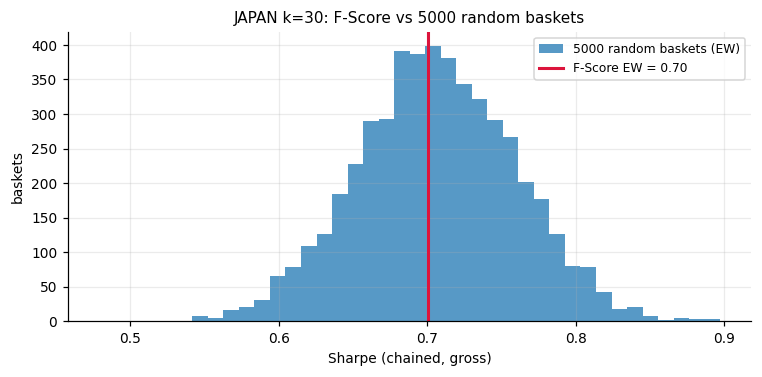

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sh = study.mc_metric(study.mc_ew, "sharpe")
ax.hist(sh, bins=40, alpha=0.75, label=f"{N_MC} random baskets (EW)")
# the placement index is (pool, statistic, basis); the histogram shows gross
fs = placement.loc[("random (full universe)", "sharpe", "gross"), "fscore"]
ax.axvline(fs, color="crimson", lw=2, label=f"F-Score EW = {fs:.2f}")
ax.set_xlabel("Sharpe (chained, gross)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: F-Score vs {N_MC} random baskets")
plt.tight_layout()
save_fig(f"{TAG}_mc_hist", directory=FIG)
plt.show()

### 4. Synergy test: per-basket optimisation gain
D = Sharpe(GMV) − Sharpe(EW), judged at the 5% level.

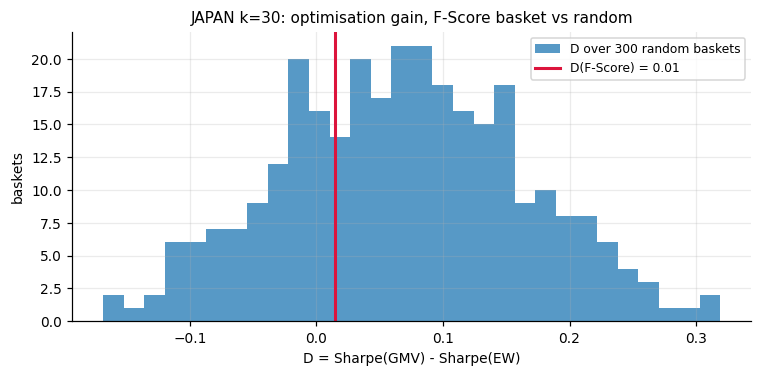

percentile       0.297
p_value          0.703
significant          0
alpha             0.05
n_draws            300
random_mean      0.068
random_std       0.095
D_fscore         0.015
D_random_mean    0.068
D_random_std     0.095
n                  300
dtype: object

In [9]:
syn = study.synergy()
d_rand = (study.mc_metric(study.mc_gmv, "sharpe")
          - study.mc_metric(study.mc_ew[list(range(study.mc_gmv.shape[1]))], "sharpe")).dropna()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(d_rand, bins=30, alpha=0.75, label=f"D over {len(d_rand)} random baskets")
ax.axvline(syn["D_fscore"], color="crimson", lw=2,
           label=f"D(F-Score) = {syn['D_fscore']:.2f}")
ax.set_xlabel("D = Sharpe(GMV) - Sharpe(EW)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: optimisation gain, F-Score basket vs random")
plt.tight_layout()
save_fig(f"{TAG}_synergy_hist", directory=FIG)
plt.show()
pd.Series(syn).round(3)

### 5. Track record and outputs

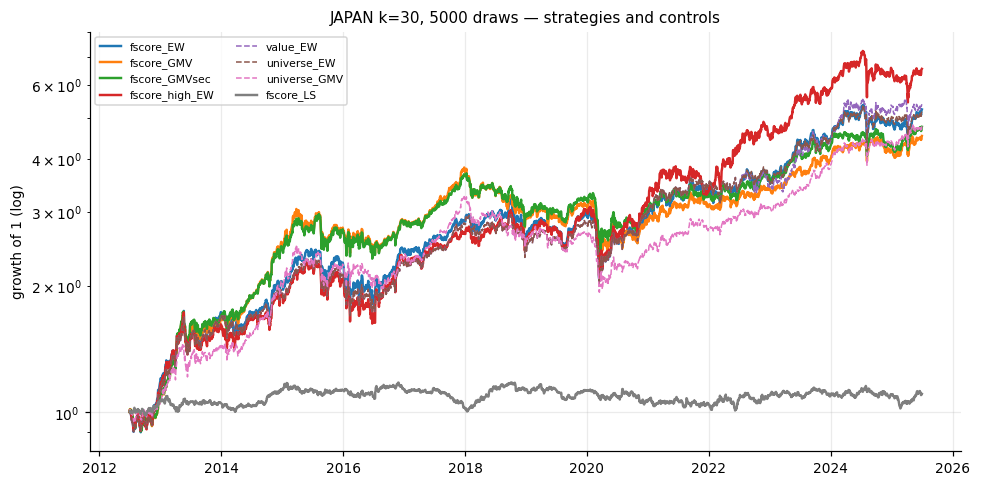

saved japan_k30_mc5000


In [10]:
nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in nav.columns:
    ax.plot(nav.index, nav[c], lw=1.6 if c.startswith("fscore") else 1.0,
            ls="-" if c.startswith("fscore") else "--", label=c)
ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)"); ax.legend(fontsize=7, ncol=2)
ax.set_title(f"{MARKET.upper()} k={K}, {N_MC} draws — strategies and controls")
plt.tight_layout()
save_fig(f"{TAG}_nav", directory=FIG)
plt.show()

summary.to_csv(OUT / f"{TAG}_summary.csv")
placement.to_csv(OUT / f"{TAG}_placement.csv")
pd.Series(syn).to_frame("value").to_csv(OUT / f"{TAG}_synergy.csv")
yearly.to_csv(OUT / f"{TAG}_yearly_returns.csv")
diag.to_csv(OUT / f"{TAG}_diagnostics.csv")
print("saved", TAG)